# Load the data

In [4]:
import pandas as pd

orders = pd.read_csv("../data/orders_analysis_final.csv")

print("Shape:", orders.shape)
print("\nColumns:")
print(orders.columns.tolist())

Shape: (14243, 73)

Columns:
['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status', 'delivery_event_count', 'failed_attempt_count', 'rto_count', 'hub_event_count', 'delivery_log_start', 'delivery_log_end', 'vehicle_count', 'delivery_delay_hours', 'delivery_delay_pct', 'on_time', 'order_date_dt', 'traffic_date', 'traffic_hour', 'city_x', 'hour_of_day', 'congestion_index', 'traffic_avg_speed_kmph', 'incident_reported', 'road_closure', 'weather_date', 'weather_city', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmph', 'visibility_km', 'temp_celsius', 'storm_alert', 'condition', '

# Identify route-related features

In [5]:
route_columns = [
    'order_id',
    'origin_hub',
    'origin_city',
    'destination_city',
    'destination_state',
    'destination_lat',
    'destination_lon',
    'distance_km',
    'package_weight',
    'transport_mode',
    'vehicle_id',
    'vehicle_type',
    'capacity_kg',
    'max_range_km',
    'vehicle_avg_speed_kmph',
    'vehicle_capacity_utilization_pct',
    'weight_exceeds_capacity',
    'delivery_priority'
]

route_data = orders[route_columns].copy()

print("Route data shape:", route_data.shape)
print("\nMissing values:")
print(route_data.isnull().sum())

Route data shape: (14243, 18)

Missing values:
order_id                               0
origin_hub                             0
origin_city                            0
destination_city                       0
destination_state                      0
destination_lat                        0
destination_lon                        0
distance_km                          113
package_weight                         0
transport_mode                         0
vehicle_id                           498
vehicle_type                         498
capacity_kg                          498
max_range_km                         498
vehicle_avg_speed_kmph               498
vehicle_capacity_utilization_pct    1351
weight_exceeds_capacity                0
delivery_priority                      0
dtype: int64


# Handle distance_km

In [6]:
route_data['distance_km'] = route_data['distance_km'].fillna(
    route_data['distance_km'].median()
)

print(
    "distance_km missing values:",
    route_data['distance_km'].isnull().sum()
)

distance_km missing values: 0


Check vehicle-related missing values

In [7]:
print(
    route_data[route_data['vehicle_id'].isnull()]
    [['transport_mode', 'package_weight', 'distance_km',
      'vehicle_id', 'vehicle_type', 'capacity_kg',
      'max_range_km', 'vehicle_avg_speed_kmph']]
    .head(10)
)

    transport_mode  package_weight  distance_km vehicle_id vehicle_type  \
29       air cargo            0.43      1657.31        NaN          NaN   
108      air cargo            5.16      1286.68        NaN          NaN   
128      air cargo           20.76      1281.07        NaN          NaN   
168          truck            4.58       437.31        NaN          NaN   
298           bike            4.36         7.59        NaN          NaN   
301          truck            0.72       312.36        NaN          NaN   
303          truck           75.10       363.75        NaN          NaN   
312           bike            5.44        13.16        NaN          NaN   
358           bike            9.95        10.83        NaN          NaN   
369          truck            6.20       142.07        NaN          NaN   

     capacity_kg  max_range_km  vehicle_avg_speed_kmph  
29           NaN           NaN                     NaN  
108          NaN           NaN                     NaN  
128

Check how many records have missing vehicle information

In [8]:
print("Rows with missing vehicle:", route_data['vehicle_id'].isnull().sum())

print("\nTransport modes for missing vehicles:")
print(
    route_data.loc[
        route_data['vehicle_id'].isnull(),
        'transport_mode'
    ].value_counts()
)

Rows with missing vehicle: 498

Transport modes for missing vehicles:
transport_mode
truck        219
bike         119
van           72
air cargo     61
drone         22
ship           5
Name: count, dtype: int64


Remove records without an assigned vehicle

In [9]:
route_data = route_data.dropna(
    subset=['vehicle_id']
).copy()

print("Route data shape:", route_data.shape)
print(
    "Missing vehicle IDs:",
    route_data['vehicle_id'].isnull().sum()
)

Route data shape: (13745, 18)
Missing vehicle IDs: 0


Check remaining vehicle-related missing values

In [10]:
print(
    route_data[
        [
            'vehicle_type',
            'capacity_kg',
            'max_range_km',
            'vehicle_avg_speed_kmph',
            'vehicle_capacity_utilization_pct'
        ]
    ].isnull().sum()
)

vehicle_type                          0
capacity_kg                           0
max_range_km                          0
vehicle_avg_speed_kmph                0
vehicle_capacity_utilization_pct    853
dtype: int64


 Calculate actual capacity utilization

In [11]:
route_data['calculated_capacity_utilization_pct'] = (
    route_data['package_weight'] /
    route_data['capacity_kg']
) * 100

print(
    route_data['calculated_capacity_utilization_pct']
    .describe()
)

count     13745.000000
mean        475.517717
std       14061.682074
min           0.000117
25%           0.075748
50%           3.724880
75%          28.815807
max      876401.538462
Name: calculated_capacity_utilization_pct, dtype: float64


Inspect the extreme cases

In [12]:
print(
    route_data[
        [
            'vehicle_id',
            'vehicle_type',
            'package_weight',
            'capacity_kg',
            'calculated_capacity_utilization_pct'
        ]
    ]
    .sort_values(
        'calculated_capacity_utilization_pct',
        ascending=False
    )
    .head(10)
)

      vehicle_id vehicle_type  package_weight  capacity_kg  \
10337   VEH-0051        Drone        11393.22          1.3   
14054   VEH-0015        Drone        11913.03          1.4   
13620   VEH-0015        Drone         7470.63          1.4   
11635   VEH-0116        Drone         7433.61          1.5   
13493   VEH-0135        Drone         7258.94          1.8   
12035   VEH-0087        Drone        17572.28          5.9   
13955   VEH-0033        Drone        15477.28          5.6   
11250   VEH-0002        Drone         7241.46          2.8   
11290   VEH-0121        Drone        12651.66          5.1   
5474    VEH-0094        Drone        12767.88          5.3   

       calculated_capacity_utilization_pct  
10337                        876401.538462  
14054                        850930.714286  
13620                        533616.428571  
11635                        495574.000000  
13493                        403274.444444  
12035                        297835.254237  
13

Check capacity by vehicle type

In [13]:
print(
    route_data.groupby('vehicle_type')['capacity_kg']
    .describe()
)

               count           mean            std       min       25%  \
vehicle_type                                                             
Air Cargo     1856.0   27108.524623   10885.625654    9924.4   16407.3   
Bike          3298.0      21.862796       7.418610      10.0      14.9   
Drone          759.0       3.708037       1.538658       1.0       2.5   
Ship           236.0  456234.068220  243819.063938  114321.3  211701.5   
Truck         5643.0   11152.694861    4336.868727    3129.7    8027.6   
Van           1953.0     806.511521     233.813523     400.3     602.6   

                   50%       75%       max  
vehicle_type                                
Air Cargo      26822.4   36497.1   44040.3  
Bike              21.2      28.7      34.9  
Drone              3.8       5.2       6.0  
Ship          510728.9  686657.9  842658.1  
Truck          11521.9   14657.3   17899.3  
Van              793.0    1005.3    1189.0  


Count capacity violations

In [14]:
route_data['calculated_weight_exceeds_capacity'] = (
    route_data['package_weight'] >
    route_data['capacity_kg']
)

print(
    route_data['calculated_weight_exceeds_capacity']
    .value_counts()
)

calculated_weight_exceeds_capacity
False    12892
True       853
Name: count, dtype: int64


Validate against the existing feature

In [15]:
comparison = pd.crosstab(
    route_data['weight_exceeds_capacity'],
    route_data['calculated_weight_exceeds_capacity']
)

print(comparison)

calculated_weight_exceeds_capacity  False  True 
weight_exceeds_capacity                         
False                               12892      0
True                                    0    853


Calculate range feasibility

In [16]:
route_data['range_feasible'] = (
    route_data['distance_km'] <= route_data['max_range_km']
)

print(route_data['range_feasible'].value_counts())

range_feasible
True     11476
False     2269
Name: count, dtype: int64


Inspect the range violations

In [17]:
print(
    route_data.loc[
        ~route_data['range_feasible'],
        'vehicle_type'
    ].value_counts()
)

vehicle_type
Truck        1652
Bike          227
Drone         157
Van           125
Air Cargo     108
Name: count, dtype: int64


Focus on Drone Range

In [18]:
drone_data = route_data[
    route_data['vehicle_type'] == 'Drone'
].copy()

print("Drone records:", len(drone_data))

print(
    drone_data[
        [
            'distance_km',
            'max_range_km',
            'package_weight',
            'capacity_kg',
            'range_feasible',
            'calculated_weight_exceeds_capacity'
        ]
    ].describe()
)

Drone records: 759
       distance_km  max_range_km  package_weight  capacity_kg
count   759.000000    759.000000      759.000000   759.000000
mean    141.991357     17.803689      202.007589     3.708037
std     402.262331      7.748151     1394.261507     1.538658
min       0.190000    -20.600000        0.240000     1.000000
25%       4.205000     13.300000        1.380000     2.500000
50%       6.200000     17.700000        2.440000     3.800000
75%      10.830000     23.900000        4.260000     5.200000
max    2318.040000     29.900000    17572.280000     6.000000


Count invalid drone range values

In [19]:
print("Negative drone max_range:", 
      (drone_data['max_range_km'] < 0).sum())

print("Zero drone max_range:", 
      (drone_data['max_range_km'] == 0).sum())

print("Drone distance > max range:", 
      (~drone_data['range_feasible']).sum())

Negative drone max_range: 13
Zero drone max_range: 0
Drone distance > max range: 157


Inspect the 13 invalid drone records

In [20]:
print(
    drone_data.loc[
        drone_data['max_range_km'] < 0,
        [
            'vehicle_id',
            'vehicle_type',
            'distance_km',
            'max_range_km',
            'package_weight',
            'capacity_kg',
            'range_feasible',
            'calculated_weight_exceeds_capacity'
        ]
    ]
)

      vehicle_id vehicle_type  distance_km  max_range_km  package_weight  \
9       VEH-0046        Drone         3.45          -8.6            2.66   
579     VEH-0046        Drone         5.29          -8.6           10.59   
990     VEH-0139        Drone         4.79         -20.6            1.22   
1999    VEH-0139        Drone         7.74         -20.6            2.08   
2358    VEH-0139        Drone         2.64         -20.6            1.04   
2966    VEH-0046        Drone         6.37          -8.6           10.59   
5341    VEH-0046        Drone       987.00          -8.6         1481.58   
6189    VEH-0139        Drone         6.41         -20.6            3.20   
6220    VEH-0139        Drone        10.82         -20.6            1.08   
10645   VEH-0139        Drone         4.83         -20.6            3.36   
12057   VEH-0139        Drone         4.53         -20.6            4.53   
12064   VEH-0046        Drone         5.57          -8.6            2.08   
13884   VEH-

Create a valid drone range constraint

In [21]:
route_data['valid_range_feasible'] = (
    (route_data['max_range_km'] > 0) &
    (route_data['distance_km'] <= route_data['max_range_km'])
)

print(route_data['valid_range_feasible'].value_counts())

valid_range_feasible
True     11476
False     2269
Name: count, dtype: int64


Combine capacity + range

In [22]:
route_data['capacity_feasible'] = (
    route_data['package_weight'] <= route_data['capacity_kg']
)

route_data['route_feasible'] = (
    route_data['capacity_feasible'] &
    route_data['valid_range_feasible']
)

print(route_data['route_feasible'].value_counts())

route_feasible
True     10813
False     2932
Name: count, dtype: int64


Find out why routes are infeasible

In [23]:
print(
    pd.crosstab(
        route_data['capacity_feasible'],
        route_data['valid_range_feasible']
    )
)

valid_range_feasible  False  True 
capacity_feasible                 
False                   190    663
True                   2079  10813


Add delivery priority

In [24]:
print(route_data['delivery_priority'].value_counts())

delivery_priority
standard    6902
express     3771
same-day    1672
economy     1400
Name: count, dtype: int64


Create a scheduling priority score

In [25]:
priority_map = {
    'same-day': 4,
    'express': 3,
    'standard': 2,
    'economy': 1
}

route_data['priority_score'] = (
    route_data['delivery_priority'].map(priority_map)
)

print(route_data['priority_score'].value_counts().sort_index())

priority_score
1    1400
2    6902
3    3771
4    1672
Name: count, dtype: int64


Calculate estimated travel time

In [26]:
route_data['estimated_travel_hours'] = (
    route_data['distance_km'] /
    route_data['vehicle_avg_speed_kmph']
)

print(route_data['estimated_travel_hours'].describe())

count    13745.000000
mean         7.784310
std         11.847271
min          0.001615
25%          0.244839
50%          1.505140
75%         12.388246
max         89.943333
Name: estimated_travel_hours, dtype: float64


Create a scheduling score

In [27]:
route_data['scheduling_score'] = (
    route_data['priority_score'] * 1000
    + route_data['route_feasible'].astype(int) * 100
    - route_data['estimated_travel_hours']
)

print(
    route_data[
        [
            'delivery_priority',
            'priority_score',
            'route_feasible',
            'estimated_travel_hours',
            'scheduling_score'
        ]
    ].head()
)

  delivery_priority  priority_score  route_feasible  estimated_travel_hours  \
0           economy               1            True               11.465962   
1           express               3            True                0.340444   
2           express               3            True                0.285238   
3          standard               2            True                0.057857   
4          standard               2           False               42.655652   

   scheduling_score  
0       1088.534038  
1       3099.659556  
2       3099.714762  
3       2099.942143  
4       1957.344348  


Create the final delivery schedule

In [28]:
optimized_routes = route_data.sort_values(
    by=[
        'priority_score',
        'route_feasible',
        'estimated_travel_hours'
    ],
    ascending=[
        False,
        False,
        True
    ]
).copy()

print("Optimized route data shape:", optimized_routes.shape)

print(
    optimized_routes[
        [
            'order_id',
            'origin_city',
            'destination_city',
            'vehicle_type',
            'distance_km',
            'delivery_priority',
            'route_feasible',
            'estimated_travel_hours'
        ]
    ].head(10)
)

Optimized route data shape: (13745, 27)
        order_id  origin_city destination_city vehicle_type  distance_km  \
7934  ORD-005690      Madurai          Madurai        Drone         0.19   
5726  ORD-012694    Bengaluru        Bengaluru    Air Cargo         5.87   
8114  ORD-000875      Kolkata          Kolkata    Air Cargo         6.33   
7290  ORD-004372       Mumbai           Mumbai    Air Cargo         7.81   
3080  ORD-005742        Kochi            Kochi    Air Cargo         8.60   
2768  ORD-014682   Chandigarh       Chandigarh    Air Cargo        10.51   
377   ORD-004126       Jaipur           Jaipur         Bike         0.57   
4503  ORD-001808      Kolkata          Kolkata         Ship         0.61   
8530  ORD-012124  Bhubaneswar      Bhubaneswar    Air Cargo        13.60   
629   ORD-014101  Bhubaneswar      Bhubaneswar    Air Cargo        15.87   

     delivery_priority  route_feasible  estimated_travel_hours  
7934          same-day            True                0.00

# Route Optimization Summary

In [29]:
print("Total route assignments:", len(route_data))

print(
    "\nRoute feasibility:"
)
print(route_data['route_feasible'].value_counts())

print(
    "\nPriority distribution in optimized schedule:"
)
print(optimized_routes['delivery_priority'].value_counts())

print(
    "\nAverage estimated travel time:",
    round(optimized_routes['estimated_travel_hours'].mean(), 2),
    "hours"
)

Total route assignments: 13745

Route feasibility:
route_feasible
True     10813
False     2932
Name: count, dtype: int64

Priority distribution in optimized schedule:
delivery_priority
standard    6902
express     3771
same-day    1672
economy     1400
Name: count, dtype: int64

Average estimated travel time: 7.78 hours


# Route Optimization Visualization

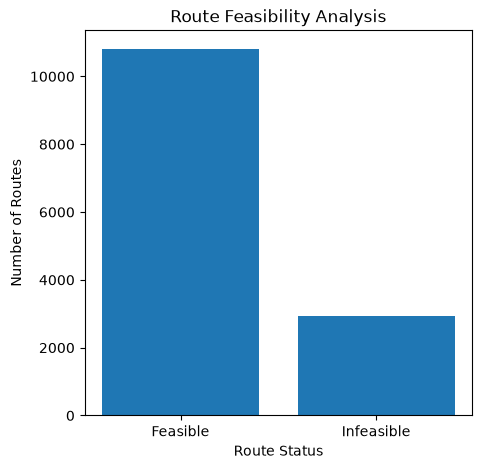

In [31]:
import matplotlib.pyplot as plt

route_status = ['Feasible', 'Infeasible']
route_counts = [
    (route_data['route_feasible'] == True).sum(),
    (route_data['route_feasible'] == False).sum()
]

plt.figure(figsize=(5, 5))

plt.bar(route_status, route_counts)

plt.xlabel("Route Status")
plt.ylabel("Number of Routes")
plt.title("Route Feasibility Analysis")

plt.show()

Priority Distribution Chart

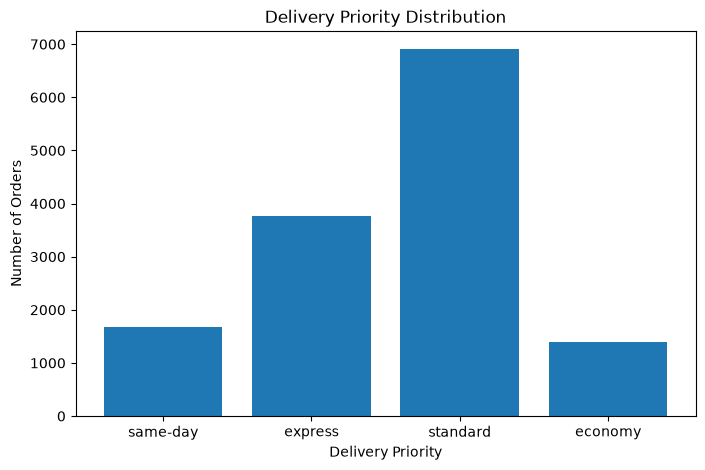

In [32]:
import matplotlib.pyplot as plt

priority_order = ['same-day', 'express', 'standard', 'economy']

priority_counts = (
    route_data['delivery_priority']
    .value_counts()
    .reindex(priority_order)
)

plt.figure(figsize=(8, 5))

plt.bar(priority_counts.index, priority_counts.values)

plt.xlabel("Delivery Priority")
plt.ylabel("Number of Orders")
plt.title("Delivery Priority Distribution")

plt.show()

# Save the optimized routes

In [33]:
optimized_routes.to_csv(
    "../data/orders_routes_optimized.csv",
    index=False
)

print("Optimized route dataset saved successfully.")

Optimized route dataset saved successfully.
